# Lab: Decision Trees with scikit-learn

In the [theory notes](./08_decision_trees_theory.md), we learned *what* a Decision Tree is — a flowchart of simple if/else questions that recursively partitions data into pure regions. In the [implementation file](./09_decision_trees_implementation.py), we built one from scratch using entropy and information gain.

**Now it's time to use the real thing.** scikit-learn's `DecisionTreeClassifier` handles all the splitting, pruning, and prediction logic for us. In this lab, we will learn how to:

1. Load and prepare a multi-class dataset.
2. Build and train a `DecisionTreeClassifier`.
3. Understand key hyperparameters (`criterion`, `max_depth`, `min_samples_split`).
4. **Visualize the tree** — the signature advantage of decision trees.
5. Inspect feature importances.
6. See how predictions are made by tracing the tree.
7. Compare how different hyperparameters change the tree structure.

---

## 1. The Dataset

We'll continue with the **Iris** dataset — three species of flowers classified by four measurements. Decision Trees are a natural fit because:
- The model's decision logic can be read directly from the tree diagram.
- Trees don't require feature scaling (they only care about thresholds, not magnitudes).
- The Iris dataset has clear, interpretable features that produce human-readable splitting rules.

Let's start by importing our libraries and loading the data.

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text

# Configurations
plt.style.use("fivethirtyeight")
sns.set_theme(style="white", palette="colorblind")
plt.rcParams["figure.figsize"] = (8, 6)
plt.rcParams["figure.dpi"] = 150

In [2]:
# Load the Iris dataset
iris = load_iris()

# Create a clean DataFrame
feature_names = [name.replace(" (cm)", "").replace(" ", "_") for name in iris.feature_names]
class_names = list(iris.target_names)
iris_df = pd.DataFrame(iris.data, columns=feature_names)
iris_df["species"] = iris.target
iris_df["species_name"] = iris.target_names[iris.target]

print(f"Dataset: {iris_df.shape[0]} samples, {len(feature_names)} features, {len(class_names)} classes")
print(f"Classes: {class_names}")
print(f"\nSamples per class:")
print(iris_df["species_name"].value_counts().to_string())
print()
iris_df.head()

Dataset: 150 samples, 4 features, 3 classes
Classes: [np.str_('setosa'), np.str_('versicolor'), np.str_('virginica')]

Samples per class:
species_name
setosa        50
versicolor    50
virginica     50



,sepal_length,sepal_width,petal_length,petal_width,species,species_name
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


---

## 2. Preparing the Data

We separate features from the target. Note that **no scaling is needed** — this is one of the key advantages of decision trees. Because each split is a simple threshold comparison (e.g., "is petal_length ≤ 2.45?"), the absolute magnitude of features doesn't matter. A feature measured in millimeters would produce the same tree structure as one measured in meters.

> 📌 **No StandardScaler needed!** Unlike Logistic Regression (which we scaled in the previous lab), Decision Trees are invariant to feature scaling. This is because they split on thresholds, not on distances or gradients.

In [3]:
# Separate features and target — no scaling needed for decision trees
X = iris_df[feature_names].values
y = iris_df["species"].values

print(f"Shape of X: {X.shape}")
print(f"Shape of y: {y.shape}")

Shape of X: (150, 4)
Shape of y: (150,)


---

## 3. Building a Decision Tree Classifier

Let's start by building a decision tree with default parameters. The key parameters to know are:

| Parameter | What It Does | Default |
|---|---|---|
| `criterion` | The impurity measure used for splitting (`"gini"` or `"entropy"`) | `"gini"` |
| `max_depth` | Maximum depth of the tree (limits how many levels of splits) | `None` (unlimited) |
| `min_samples_split` | Minimum samples needed to split a node | `2` |
| `min_samples_leaf` | Minimum samples required to be in a leaf node | `1` |
| `random_state` | Seed for reproducibility (used when splits have equal quality) | `None` |

With defaults, the tree will grow until every leaf is pure (contains only one class). Let's see what that looks like:

In [4]:
# Build a Decision Tree with default parameters
clf = DecisionTreeClassifier(random_state=42)
clf.fit(X, y)

print("Decision Tree trained!")
print(f"Tree depth: {clf.get_depth()}")
print(f"Number of leaves: {clf.get_n_leaves()}")
print(f"Number of features used: {clf.n_features_in_}")
print(f"Classes: {clf.classes_}")
print(f"Splitting criterion: {clf.criterion}")

Decision Tree trained!
Tree depth: 5
Number of leaves: 9
Number of features used: 4
Classes: [0 1 2]
Splitting criterion: gini


---

## 4. Visualizing the Tree

This is the **signature advantage** of decision trees — you can literally *see* how the model makes decisions. Each node shows:
- The **splitting rule** (e.g., `petal_length <= 2.45`)
- The **impurity** (Gini value — how mixed the classes are)
- The **sample count** (how many training samples reached this node)
- The **class distribution** (how many samples of each class are in this node)
- The **predicted class** (the majority class at this node)

### 4.1. Graphical Tree Plot

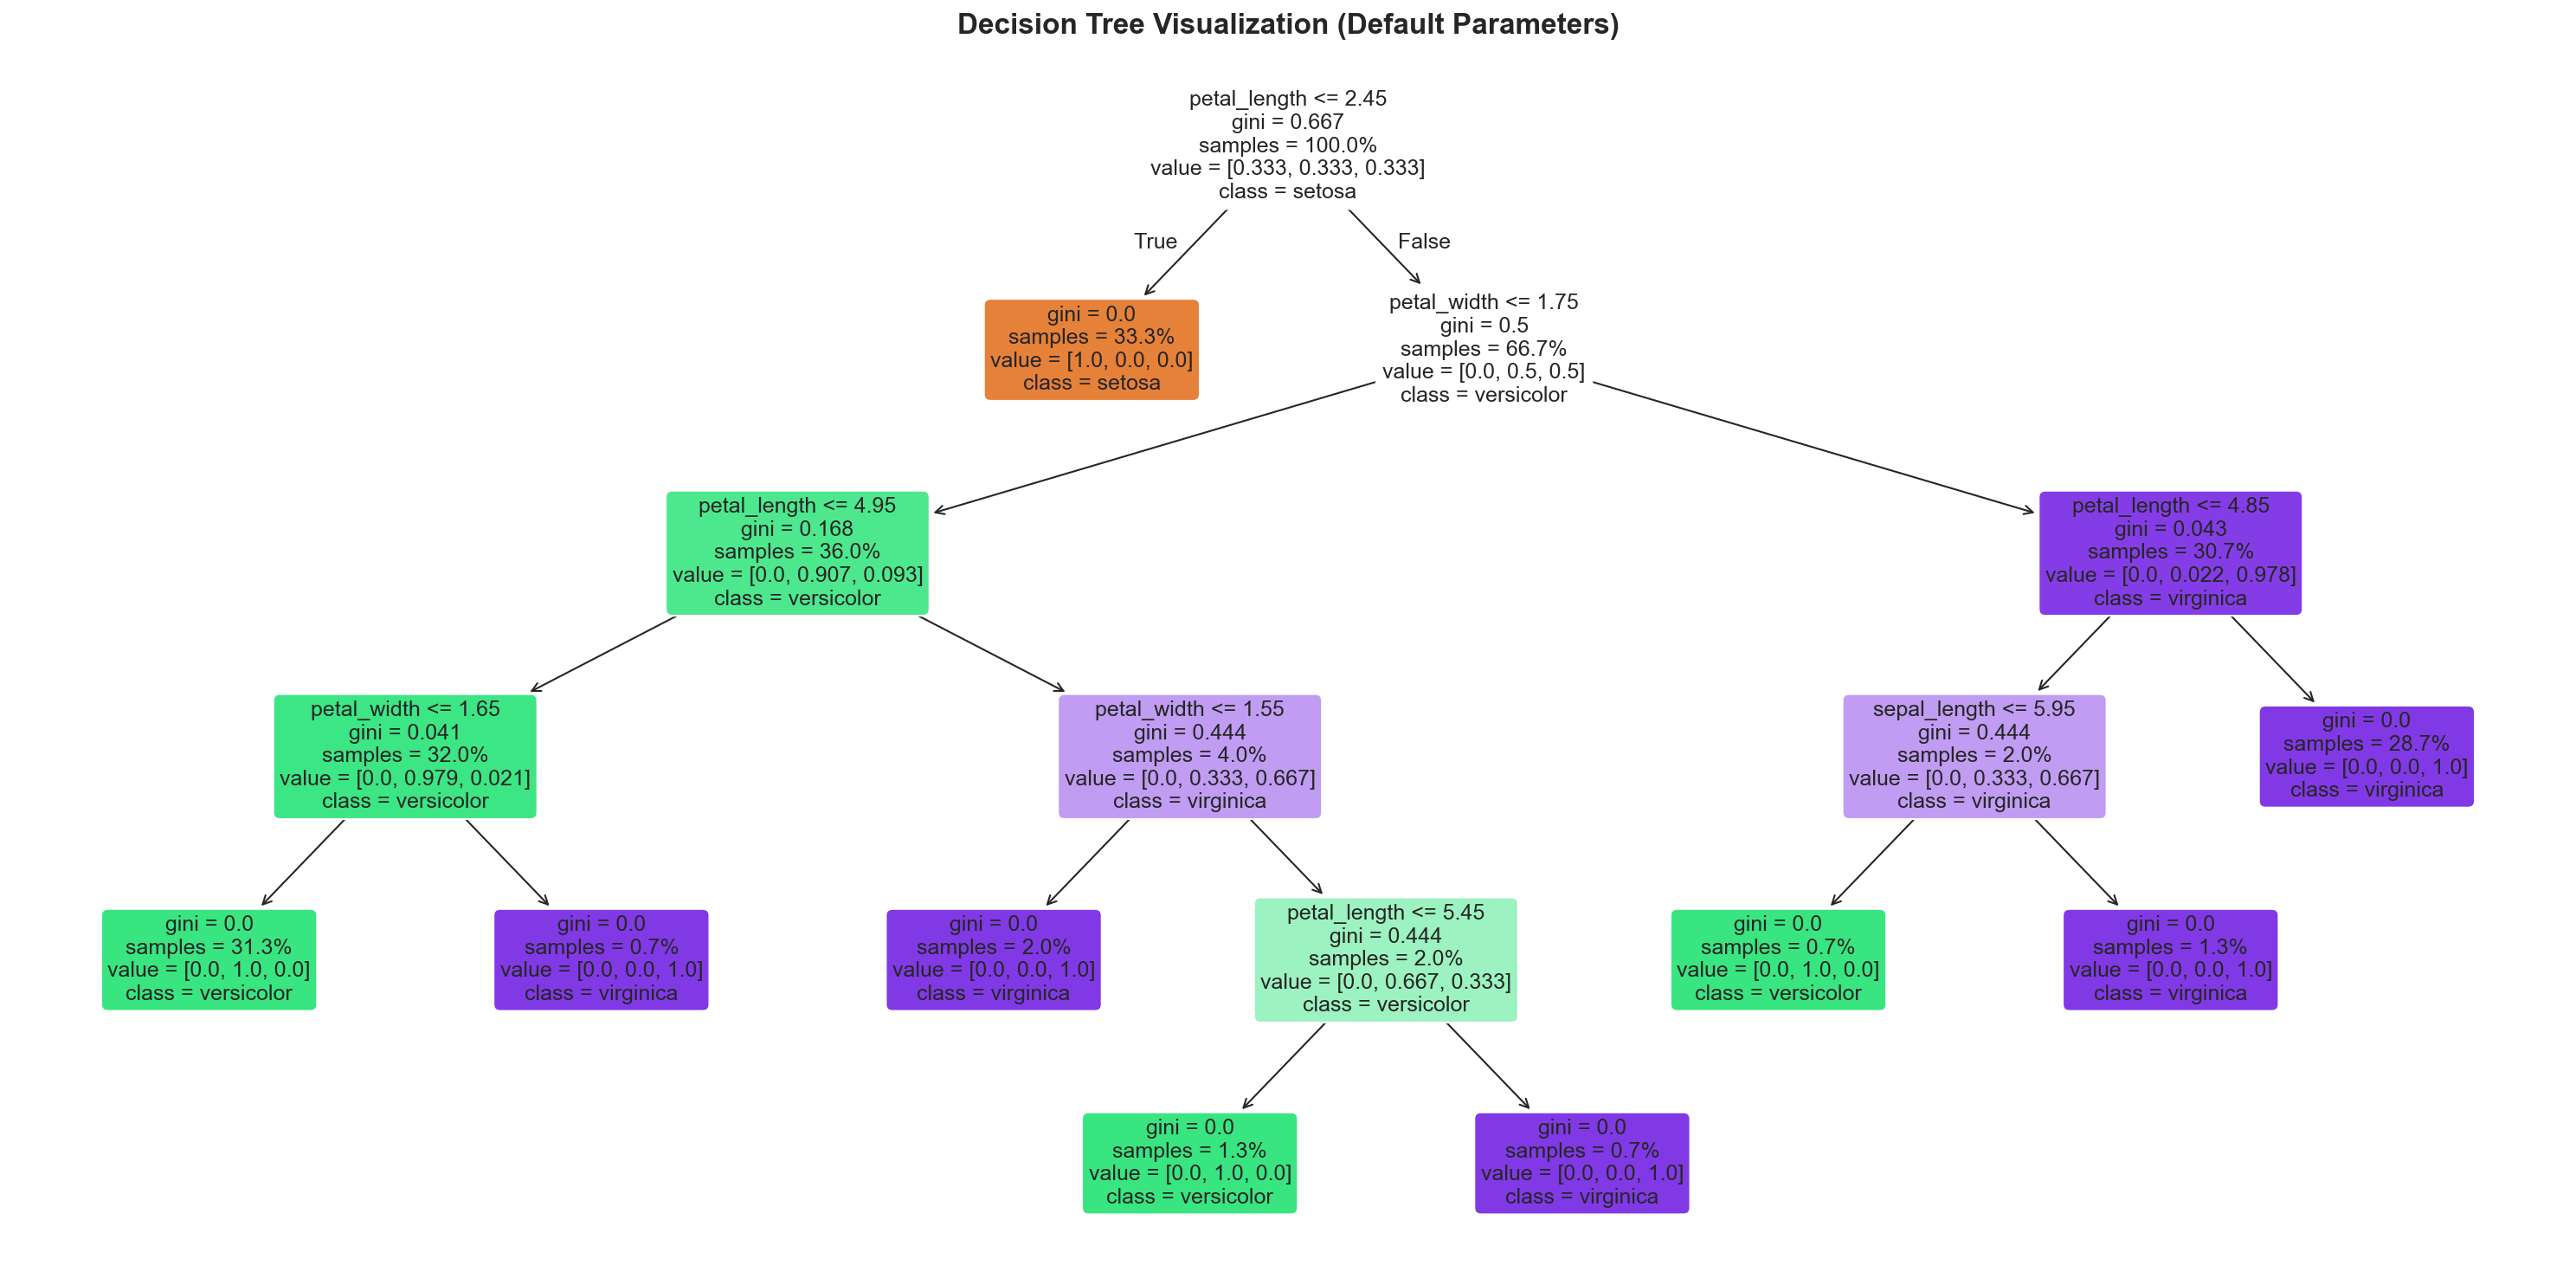

In [5]:
plt.figure(figsize=(20, 10))
plot_tree(
    clf,
    feature_names=feature_names,
    class_names=class_names,
    filled=True,
    rounded=True,
    fontsize=12,
    impurity=True,
    proportion=True
)
plt.title("Decision Tree Visualization (Default Parameters)", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.show()

### 📌 How to Read the Tree

1. **Start at the root** (top node). The first question is about `petal_length`.
2. **Follow left** if the condition is `True` (≤ threshold), **right** if `False` (> threshold).
3. **Leaf nodes** (bottom) give the final prediction — the class with the most samples.
4. **Colors** indicate the dominant class: each class gets a different color, and deeper colors mean higher purity.

Notice how **setosa** is perfectly separated with just one split (`petal_length ≤ 2.45`). The remaining splits try to distinguish between **versicolor** and **virginica**, which overlap more in feature space.

### 4.2. Text-Based Tree (Exportable Rules)

scikit-learn can also export the tree as a text-based rule set. This is useful for documentation or when you need to implement the rules in another system:

In [6]:
# Export tree rules as text
tree_rules = export_text(clf, feature_names=feature_names)
print("Decision Rules:")
print(tree_rules)

Decision Rules:
|--- petal_length <= 2.45
|   |--- class: 0
|--- petal_length >  2.45
|   |--- petal_width <= 1.75
|   |   |--- petal_length <= 4.95
|   |   |   |--- petal_width <= 1.65
|   |   |   |   |--- class: 1
|   |   |   |--- petal_width >  1.65
|   |   |   |   |--- class: 2
|   |   |--- petal_length >  4.95
|   |   |   |--- petal_width <= 1.55
|   |   |   |   |--- class: 2
|   |   |   |--- petal_width >  1.55
|   |   |   |   |--- petal_length <= 5.45
|   |   |   |   |   |--- class: 1
|   |   |   |   |--- petal_length >  5.45
|   |   |   |   |   |--- class: 2
|   |--- petal_width >  1.75
|   |   |--- petal_length <= 4.85
|   |   |   |--- sepal_length <= 5.95
|   |   |   |   |--- class: 1
|   |   |   |--- sepal_length >  5.95
|   |   |   |   |--- class: 2
|   |   |--- petal_length >  4.85
|   |   |   |--- class: 2



---

## 5. Tracing a Prediction

One of the great things about decision trees is that we can follow the exact path the model takes to make a prediction. Let's trace through a few example flowers:

In [7]:
# Pick one sample from each species
sample_indices = [0, 55, 110]

for i in sample_indices:
    sample = X[i]
    true_class = class_names[y[i]]
    pred_class = class_names[clf.predict(sample.reshape(1, -1))[0]]

    print(f"--- Sample {i} (true: {true_class}) ---")
    print(f"  Features: {dict(zip(feature_names, sample))}")

    # Get the decision path
    node_indicator = clf.decision_path(sample.reshape(1, -1))
    node_ids = node_indicator.indices

    tree = clf.tree_
    for node_id in node_ids:
        # If leaf node, print the prediction
        if tree.children_left[node_id] == tree.children_right[node_id]:
            print(f"  → Leaf node: predict '{pred_class}'")
        else:
            feat = feature_names[tree.feature[node_id]]
            thresh = tree.threshold[node_id]
            val = sample[tree.feature[node_id]]
            direction = "left (Yes)" if val <= thresh else "right (No)"
            print(f"  Node: Is {feat} <= {thresh:.2f}? (value={val:.1f}) → go {direction}")
    print()

--- Sample 0 (true: setosa) ---
  Features: {'sepal_length': np.float64(5.1), 'sepal_width': np.float64(3.5), 'petal_length': np.float64(1.4), 'petal_width': np.float64(0.2)}
  Node: Is petal_length <= 2.45? (value=1.4) → go left (Yes)
  → Leaf node: predict 'setosa'

--- Sample 55 (true: versicolor) ---
  Features: {'sepal_length': np.float64(5.7), 'sepal_width': np.float64(2.8), 'petal_length': np.float64(4.5), 'petal_width': np.float64(1.3)}
  Node: Is petal_length <= 2.45? (value=4.5) → go right (No)
  Node: Is petal_width <= 1.75? (value=1.3) → go left (Yes)
  Node: Is petal_length <= 4.95? (value=4.5) → go left (Yes)
  Node: Is petal_width <= 1.65? (value=1.3) → go left (Yes)
  → Leaf node: predict 'versicolor'

--- Sample 110 (true: virginica) ---
  Features: {'sepal_length': np.float64(6.5), 'sepal_width': np.float64(3.2), 'petal_length': np.float64(5.1), 'petal_width': np.float64(2.0)}
  Node: Is petal_length <= 2.45? (value=5.1) → go right (No)
  Node: Is petal_width <= 1.75?

This kind of interpretability is unique to tree-based models. For setosa, the tree needs only one question; for the other species, it needs several.

---

## 6. Feature Importances

Decision trees naturally rank features by how useful they are for splitting. A feature that appears at the root of the tree (or is used in many high-level splits) contributes more to reducing impurity and is considered more "important."

scikit-learn computes this as the **Gini importance** (or mean decrease in impurity) — a weighted sum of how much each feature reduces impurity across all nodes where it's used.

Feature Importances (Gini Importance):
     Feature  Importance
petal_length    0.564056
 petal_width    0.422611
sepal_length    0.013333
 sepal_width    0.000000


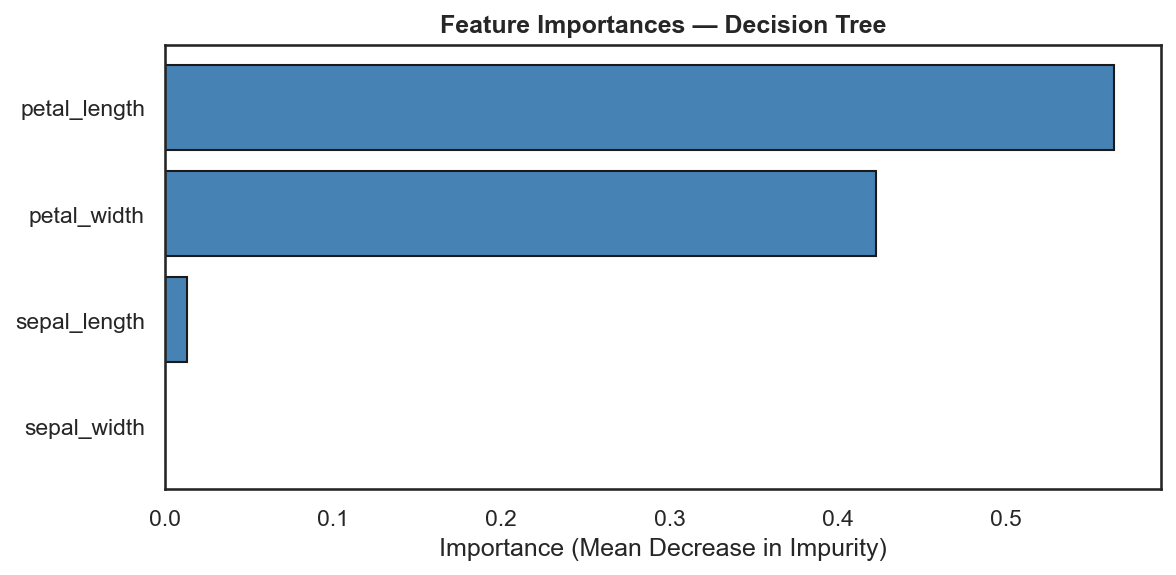

In [8]:
# Get and display feature importances
importances = clf.feature_importances_

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values("Importance", ascending=False)

print("Feature Importances (Gini Importance):")
print(importance_df.to_string(index=False))

# Visualize
fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(importance_df["Feature"], importance_df["Importance"], color="steelblue", edgecolor="k")
ax.set_xlabel("Importance (Mean Decrease in Impurity)")
ax.set_title("Feature Importances — Decision Tree", fontweight="bold")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

### 📌 What This Tells Us

- **Petal measurements** dominate — `petal_width` and `petal_length` are by far the most important features. This is consistent with the tree visualization: the root split is on a petal feature, and the subsequent splits also favour petal measurements.
- **Sepal measurements** contribute very little. The tree can classify iris species almost entirely from petal geometry.

This is an example of **implicit feature selection** — one of the key advantages listed in the theory notes.

---

## 7. Effect of Hyperparameters on Tree Structure

The default tree grows until all leaves are pure, which can lead to a deep, complex tree. Let's see how key hyperparameters change the tree's shape and complexity.

### 7.1. Controlling Depth with `max_depth`

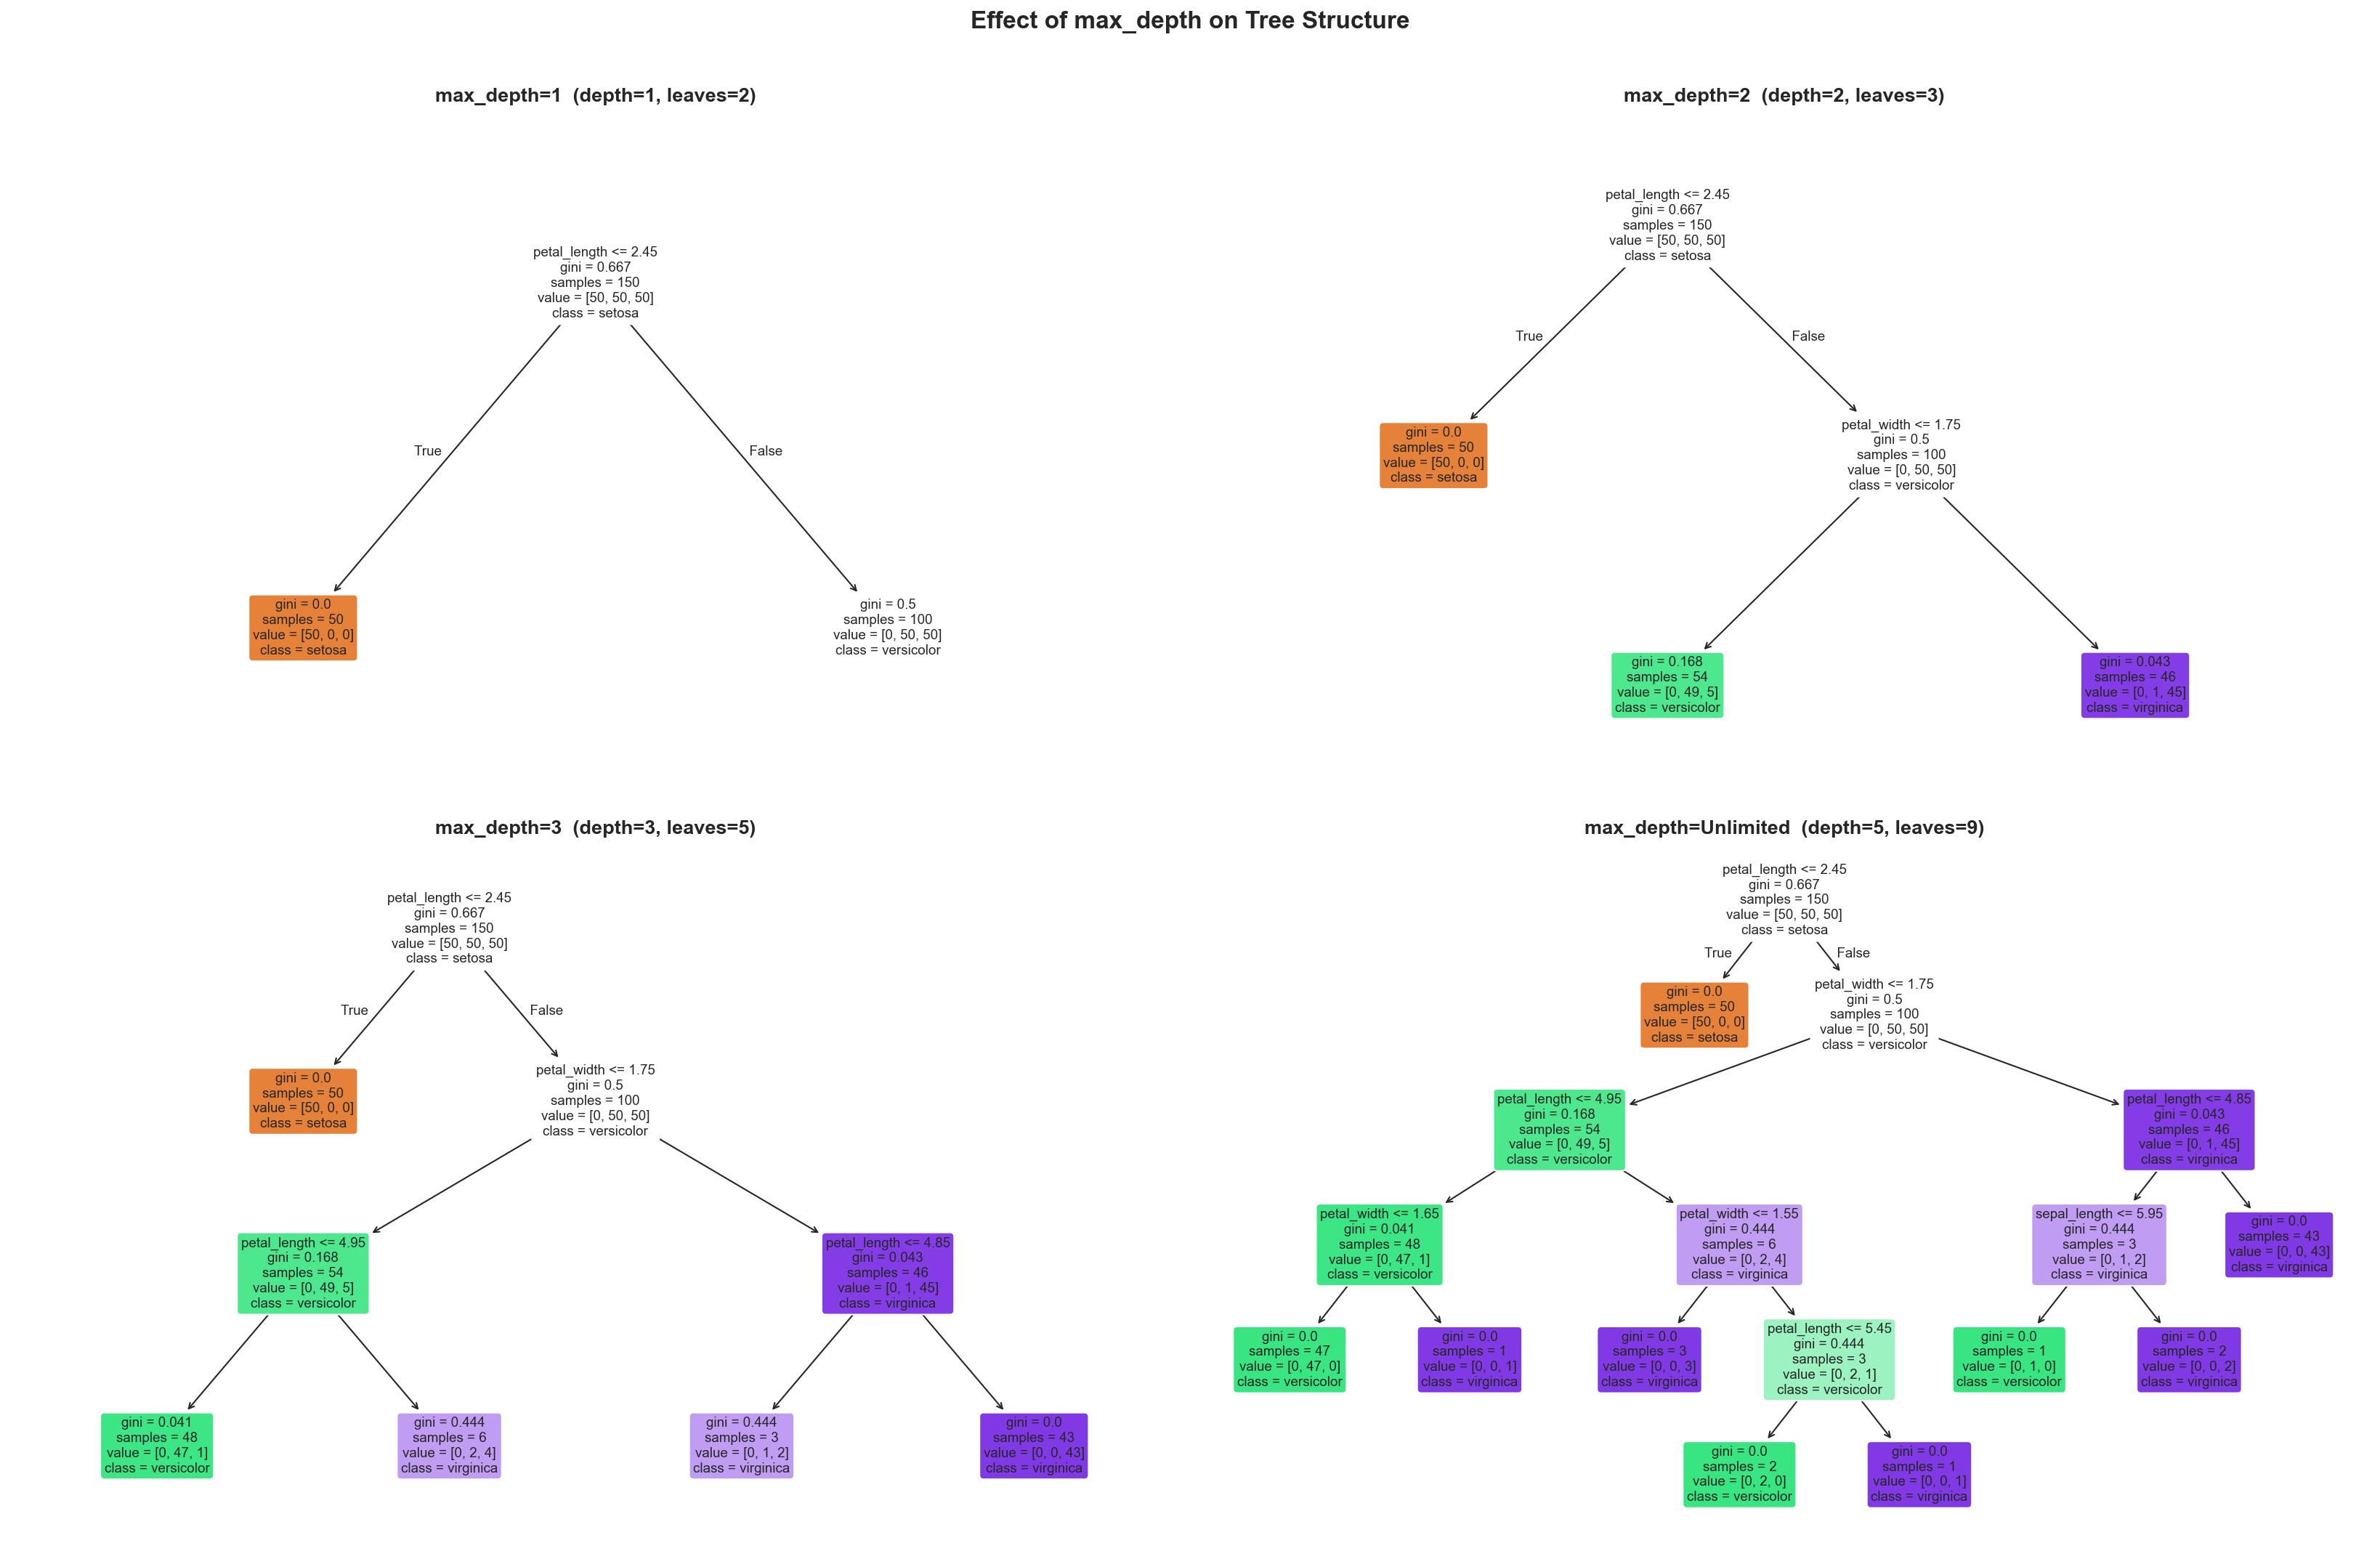

In [9]:
# Build trees with different max_depth values
depths = [1, 2, 3, None]  # None = unlimited

fig, axes = plt.subplots(2, 2, figsize=(22, 14))
axes = axes.flatten()

for ax, depth in zip(axes, depths):
    tree = DecisionTreeClassifier(max_depth=depth, random_state=42)
    tree.fit(X, y)

    depth_label = depth if depth is not None else "Unlimited"
    plot_tree(
        tree,
        feature_names=feature_names,
        class_names=class_names,
        filled=True,
        rounded=True,
        fontsize=9,
        impurity=True,
        ax=ax
    )
    ax.set_title(
        f"max_depth={depth_label}  (depth={tree.get_depth()}, leaves={tree.get_n_leaves()})",
        fontsize=13,
        fontweight="bold"
    )

fig.suptitle("Effect of max_depth on Tree Structure", fontsize=16, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

### 📌 What to Notice

- **`max_depth=1`** (a "decision stump"): Only one split — perfectly separates setosa but can't distinguish versicolor from virginica at all.
- **`max_depth=2`**: Two levels of questions — catches most of the structure with just 4 leaves.
- **`max_depth=3`**: Adds refinement for the versicolor/virginica boundary.
- **`max_depth=None`**: The tree grows until all leaves are pure. On small, clean data like Iris this is fine, but on noisy real-world data this would **overfit**.

As discussed in the theory notes, controlling `max_depth` is one of the main tools for **pre-pruning** to prevent overfitting.

### 7.2. Gini vs. Entropy

Let's compare the two splitting criteria:

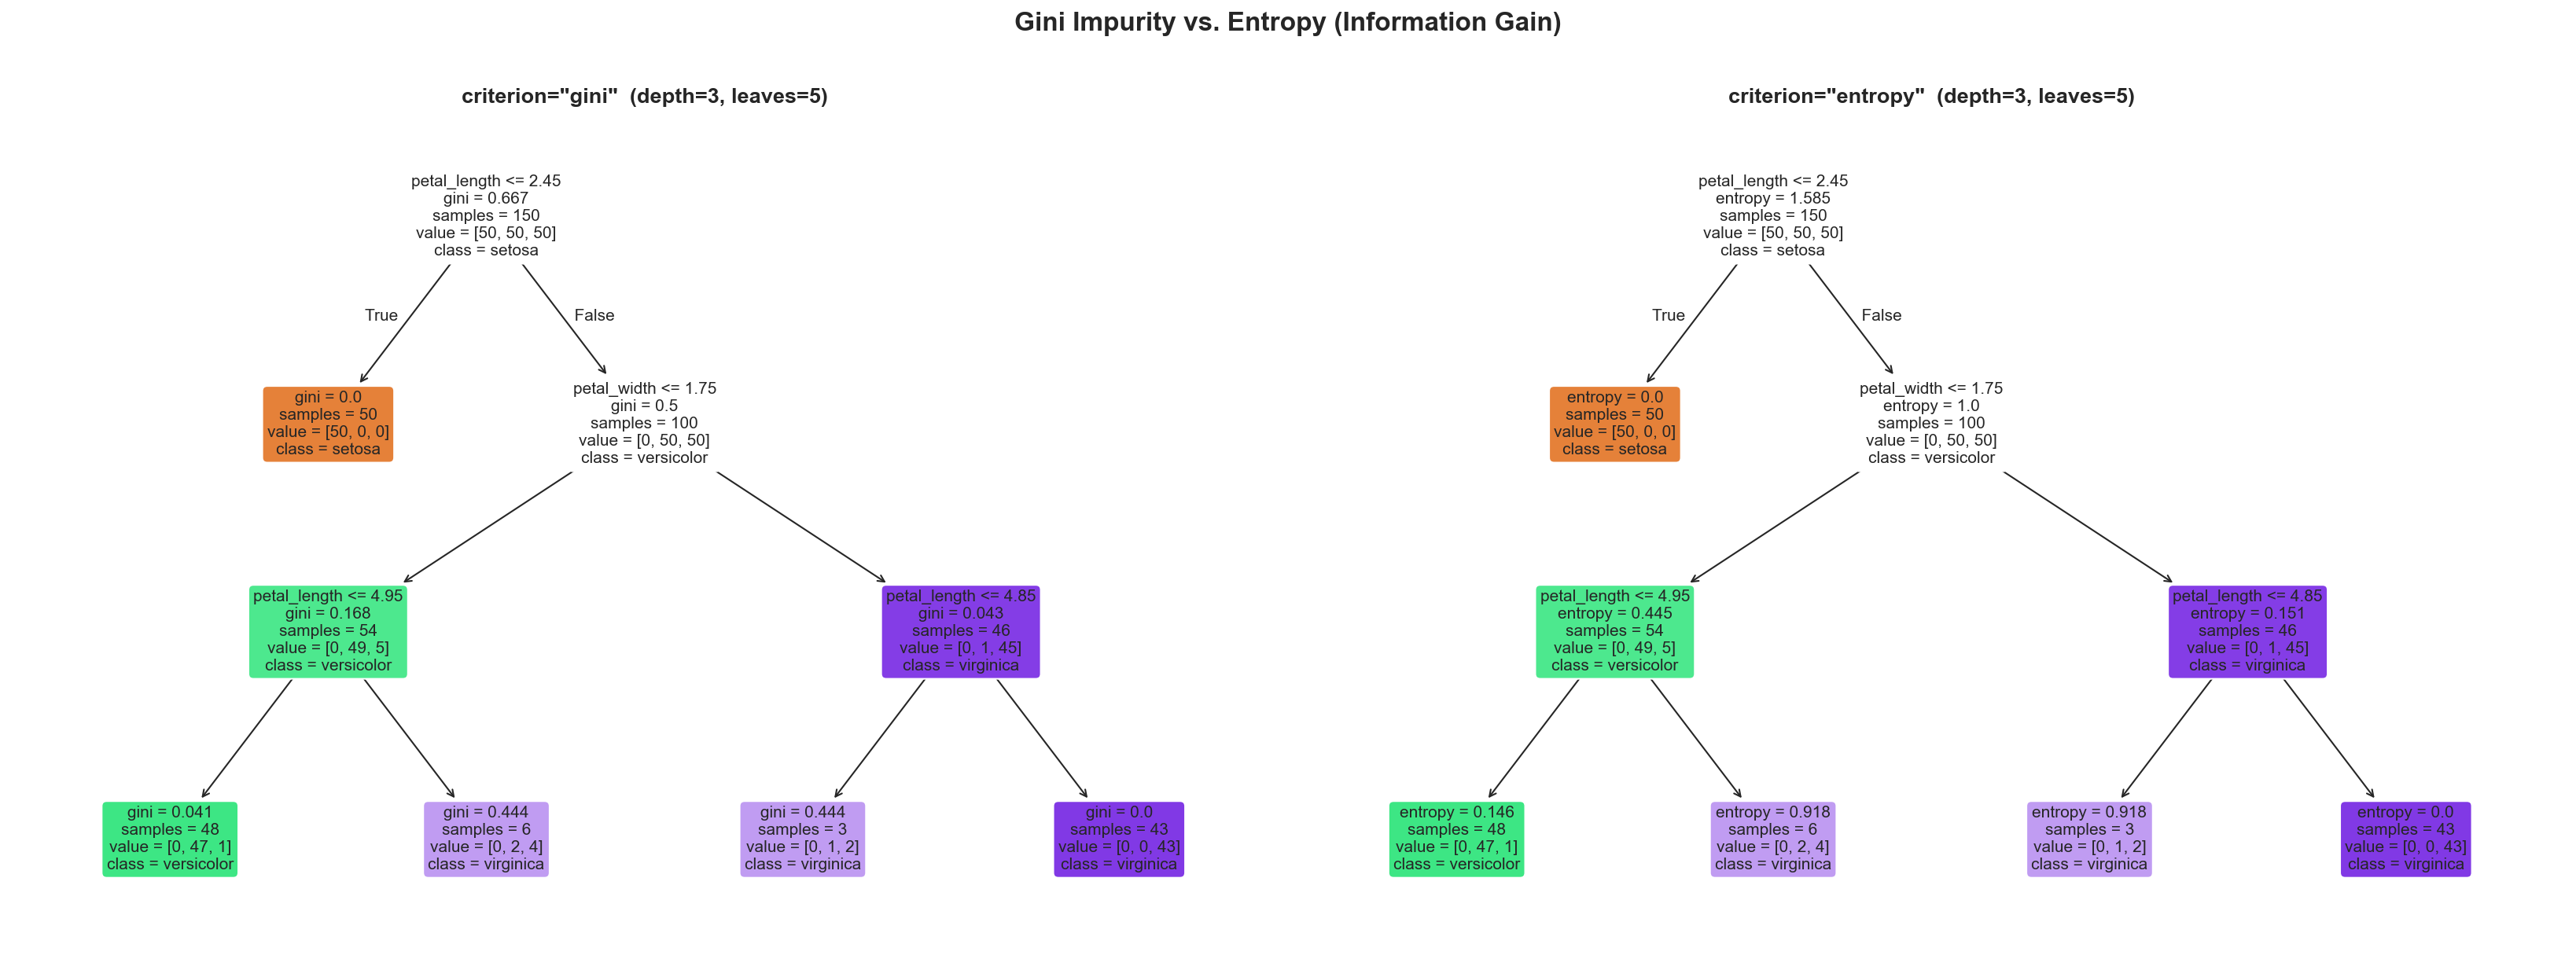

In [10]:
# Compare Gini vs Entropy
fig, axes = plt.subplots(1, 2, figsize=(22, 8))

for ax, criterion in zip(axes, ["gini", "entropy"]):
    tree = DecisionTreeClassifier(criterion=criterion, max_depth=3, random_state=42)
    tree.fit(X, y)

    plot_tree(
        tree,
        feature_names=feature_names,
        class_names=class_names,
        filled=True,
        rounded=True,
        fontsize=10,
        impurity=True,
        ax=ax
    )
    ax.set_title(
        f'criterion="{criterion}"  (depth={tree.get_depth()}, leaves={tree.get_n_leaves()})',
        fontsize=13,
        fontweight="bold"
    )

fig.suptitle("Gini Impurity vs. Entropy (Information Gain)", fontsize=16, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

### 📌 Gini vs. Entropy

In practice, the two criteria often produce very similar trees. Gini impurity is the default and is slightly faster to compute (no logarithm). Entropy (information gain) is what we implemented from scratch in the [implementation file](./09_decision_trees_implementation.py). For most datasets, the choice between them has little impact on performance.

---

## 8. Visualizing Decision Boundaries

To see how the decision tree carves up the feature space, let's use just two features (`petal_length` and `petal_width`) and plot the resulting decision regions. Tree boundaries are always **axis-aligned rectangles** — each split is a horizontal or vertical line.

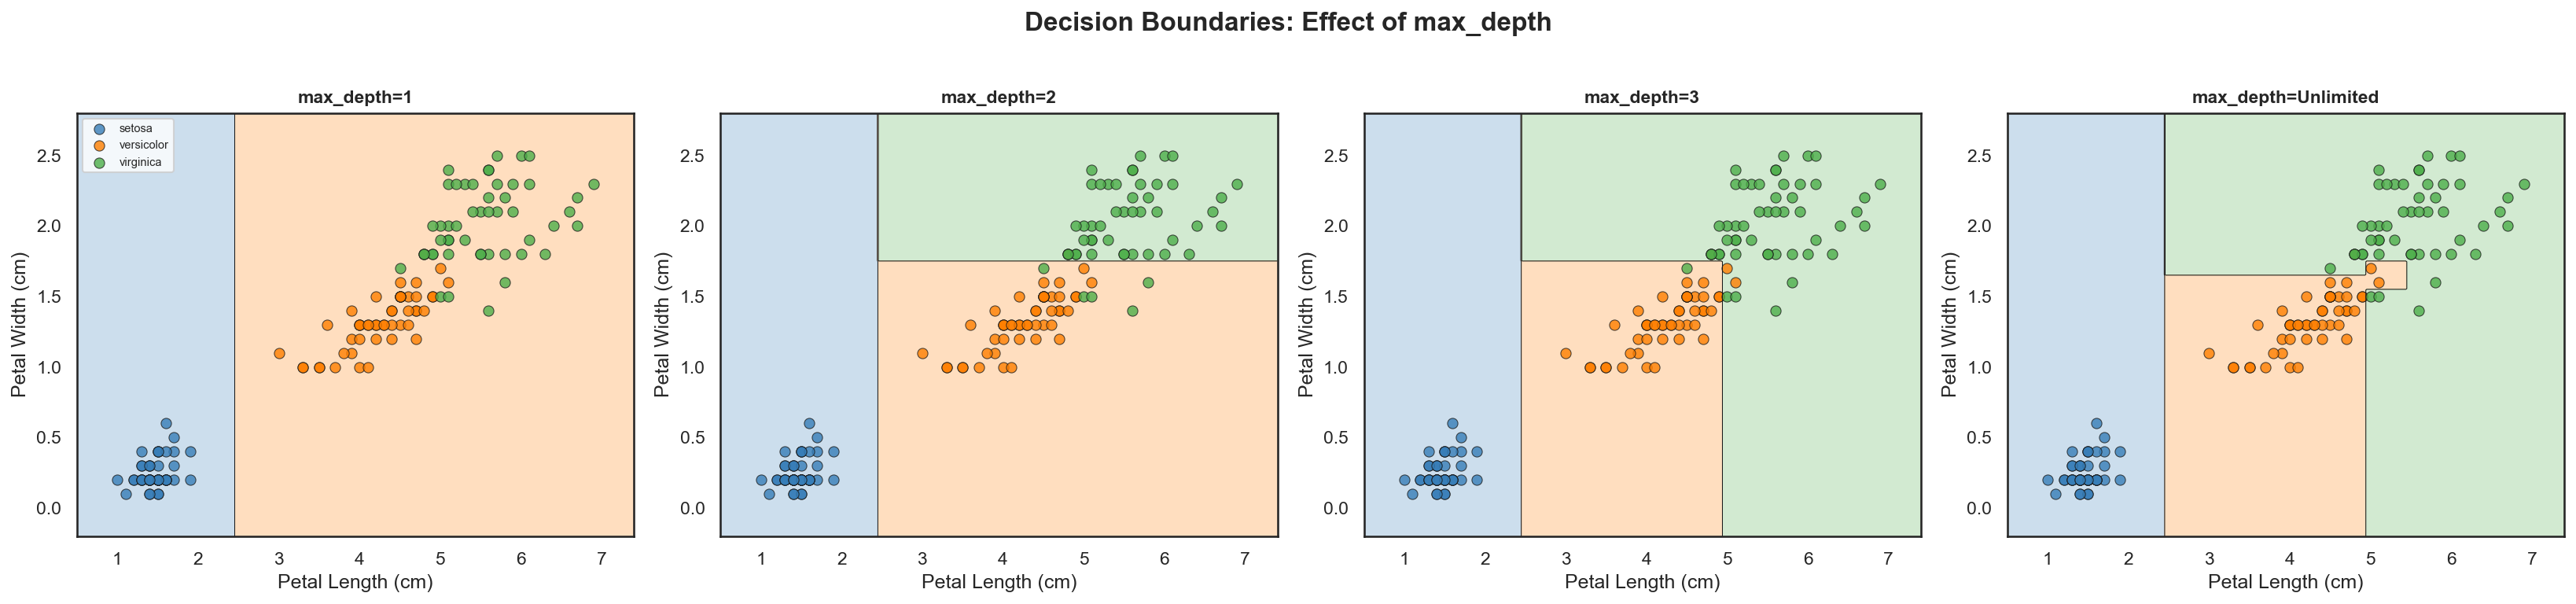

In [11]:
# Use only petal_length and petal_width for 2D visualization
X_2d = iris_df[["petal_length", "petal_width"]].values

# Train trees with different depths
depths_2d = [1, 2, 3, None]

fig, axes = plt.subplots(1, 4, figsize=(22, 5))
colors = ["#377eb8", "#ff7f00", "#4daf4a"]

for ax, depth in zip(axes, depths_2d):
    tree = DecisionTreeClassifier(max_depth=depth, random_state=42)
    tree.fit(X_2d, y)

    # Create mesh grid
    x_min, x_max = X_2d[:, 0].min() - 0.5, X_2d[:, 0].max() + 0.5
    y_min, y_max = X_2d[:, 1].min() - 0.3, X_2d[:, 1].max() + 0.3
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300), np.linspace(y_min, y_max, 300))
    grid = np.c_[xx.ravel(), yy.ravel()]

    Z = tree.predict(grid).reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.25, colors=colors, levels=[-0.5, 0.5, 1.5, 2.5])
    ax.contour(xx, yy, Z, colors="k", linewidths=0.5, levels=[0.5, 1.5])

    for cls_idx in range(3):
        mask = y == cls_idx
        ax.scatter(
            X_2d[mask, 0], X_2d[mask, 1],
            label=class_names[cls_idx],
            edgecolors="k", linewidths=0.5, s=40, alpha=0.8,
            color=colors[cls_idx]
        )

    depth_label = depth if depth is not None else "Unlimited"
    ax.set_title(f"max_depth={depth_label}", fontsize=11, fontweight="bold")
    ax.set_xlabel("Petal Length (cm)")
    ax.set_ylabel("Petal Width (cm)")
    if depth == 1:
        ax.legend(loc="upper left", fontsize=7)

fig.suptitle("Decision Boundaries: Effect of max_depth", fontsize=16, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

### 📌 Axis-Aligned Boundaries

Notice that **all boundaries are straight, horizontal, or vertical lines**. This is a fundamental characteristic of decision trees:
- Each split tests a single feature against a threshold, creating a line that is perpendicular to one axis.
- More depth = more splits = more fine-grained rectangular regions.
- With unlimited depth, the tree can create very complex, "staircase-like" boundaries to capture every training point.

Compare this to Logistic Regression (from the previous lab), which creates smooth, diagonal boundaries. Trees are more flexible but can overfit to noise in the training data.

---

## Summary

In this lab, we learned how to use scikit-learn's `DecisionTreeClassifier`. Here's what we covered:

| Step | What We Did | Key scikit-learn API |
|------|-------------|---------------------|
| Load data | Loaded the Iris dataset (3 classes) | `load_iris()` |
| No scaling | Trees are invariant to feature scaling | — |
| Build tree | Trained a `DecisionTreeClassifier` | `DecisionTreeClassifier().fit(X, y)` |
| Visualize | Plotted the full tree structure | `plot_tree()` |
| Export rules | Printed the decision rules as text | `export_text()` |
| Trace predictions | Followed the decision path for specific samples | `.decision_path()` |
| Feature importance | Inspected which features matter most | `.feature_importances_` |
| Hyperparameters | Compared `max_depth` and `criterion` effects | `max_depth`, `criterion` |
| Decision boundaries | Visualized axis-aligned region partitions | `contourf` |

The key takeaways are:

1. **Decision trees are white-box models** — you can see and explain exactly how every prediction is made.
2. **No feature scaling needed** — trees split on thresholds, not distances.
3. **`max_depth` is the most important hyperparameter** — it controls the trade-off between a simple, interpretable tree and a complex one that captures more patterns.
4. **Feature importances** are built into the model and tell you which features drive the splits.
5. **Boundaries are axis-aligned** — trees create rectangular decision regions, unlike the smooth boundaries of logistic regression.

---

**Next:** [Regression Trees Theory](./11_regression_trees_theory.md)